## 1. Data Loading and Initial Exploration



In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from category_encoders import LeaveOneOutEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')  # Updated style name for newer versions

In [ ]:
# Load the dataset
df = pd.read_csv('crop_yield_dataset.csv')

# Rename columns for consistency
df = df.rename(columns={
    "Temperature (°C)": "temperature",
    "Rainfall (mm)": "rainfall",
    "Humidity (%)": "humidity",
    "Soil Type": "soil_type",
    "Weather Condition": "weather_condition",
    "Crop Type": "crop_type",
    "Yield (tons/hectare)": "yield"
})

# Display basic information about the dataset
print("Dataset Info:")
print("=" * 50)
print(df.info())
print("\nFirst few rows:")
print("=" * 50)
display(df.head())
print("\nBasic statistics:")
print("=" * 50)
display(df.describe())

# Check for missing values
print("\nMissing values:")
print("=" * 50)
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperature        1000 non-null   float64
 1   rainfall           1000 non-null   float64
 2   humidity           1000 non-null   float64
 3   soil_type          1000 non-null   object 
 4   weather_condition  1000 non-null   object 
 5   crop_type          1000 non-null   object 
 6   yield              1000 non-null   float64
dtypes: float64(4), object(3)
memory usage: 54.8+ KB
None

First few rows:


,temperature,rainfall,humidity,soil_type,weather_condition,crop_type,yield
0,22.490802,185.132929,53.085284,Sandy,Sunny,Barley,2.818937
1,34.014286,541.900947,52.348940,Loamy,Sunny,Corn,8.014166
2,29.639879,872.945836,85.312729,Peaty,Rainy,Wheat,9.249868
3,26.973170,732.224886,52.477310,Sandy,Sunny,Soybeans,7.947481
4,18.120373,806.561148,53.597486,Clay,Stormy,Barley,6.262616



Basic statistics:


,temperature,rainfall,humidity,yield
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.805131,507.017305,65.120286,5.901829
std,5.842747,292.189893,14.533710,2.354828
min,15.092640,3.218264,40.000582,2.005020
25%,19.719465,241.074271,53.067549,3.842958
50%,24.936148,518.733906,65.030696,5.868498
75%,29.886392,760.465057,77.955176,7.929261
max,34.994353,999.413726,89.891043,9.992396



Missing values:
temperature          0
rainfall             0
humidity             0
soil_type            0
weather_condition    0
crop_type            0
yield                0
dtype: int64


## 2. Exploratory Data Analysis

Let's analyze the relationships between features and create visualizations to better understand our data.

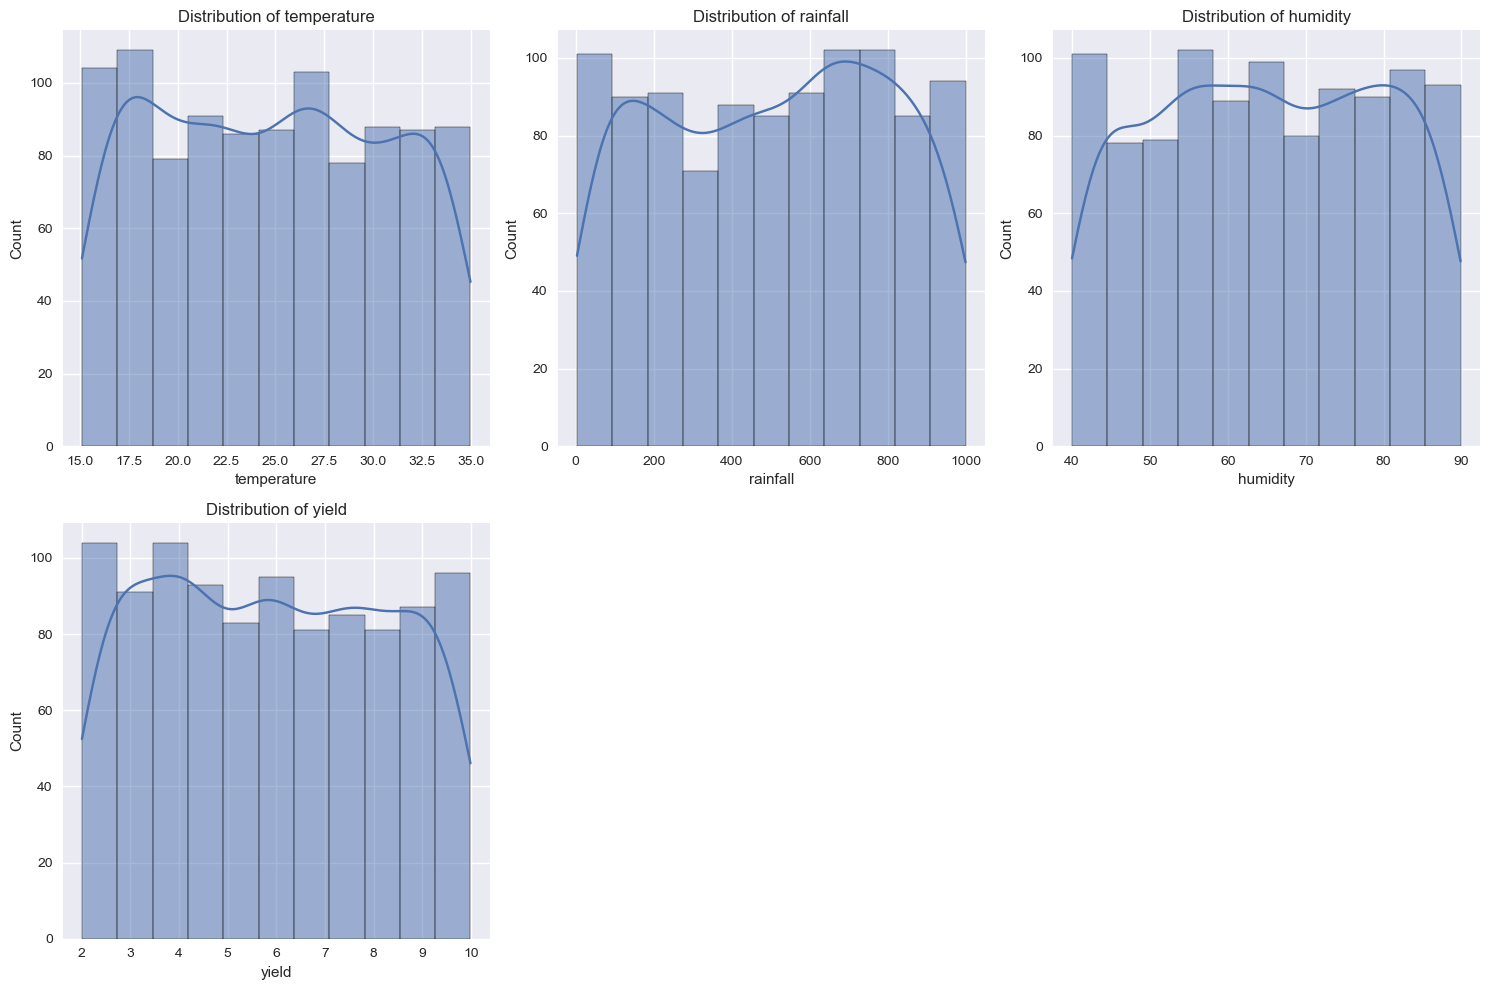

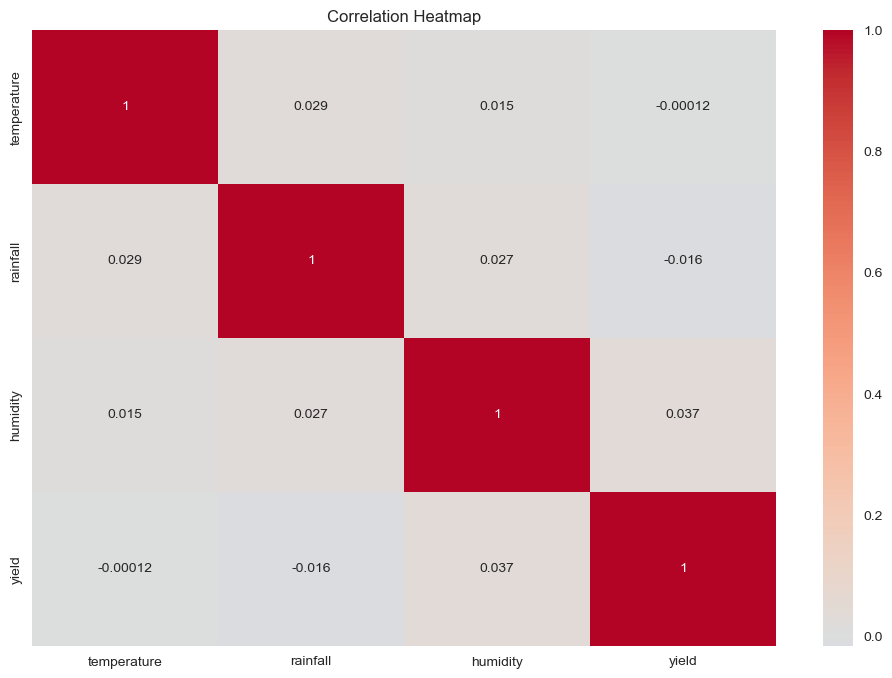

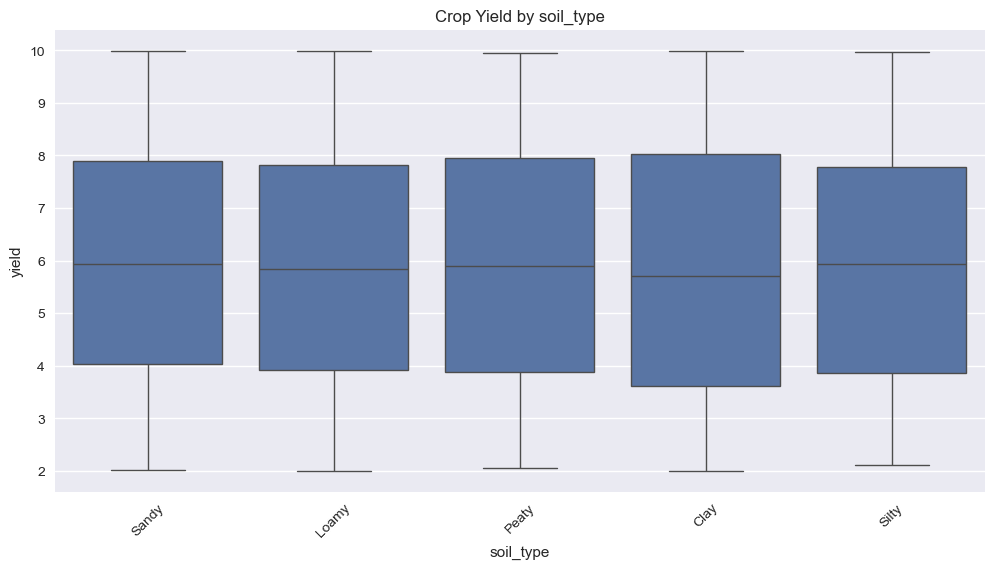

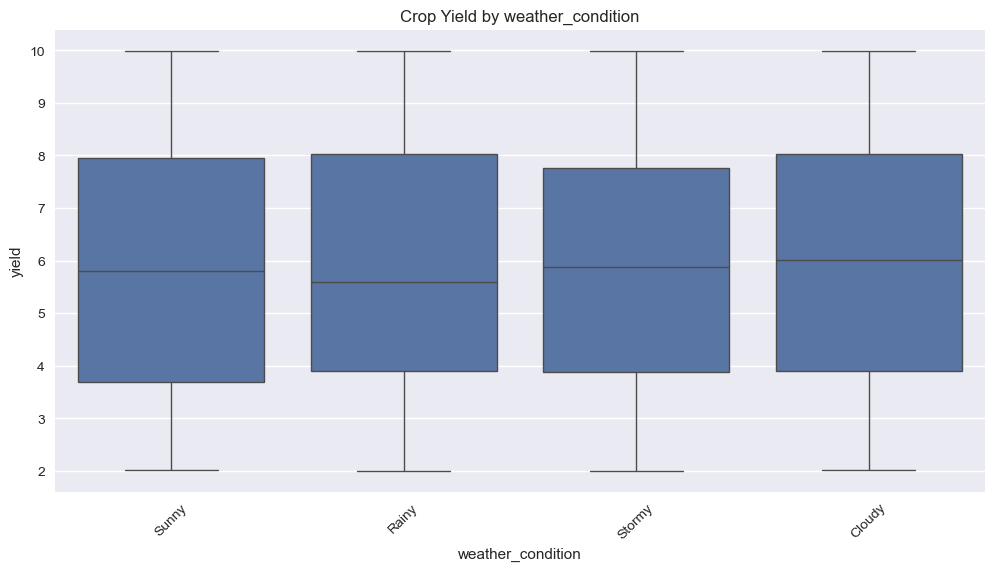

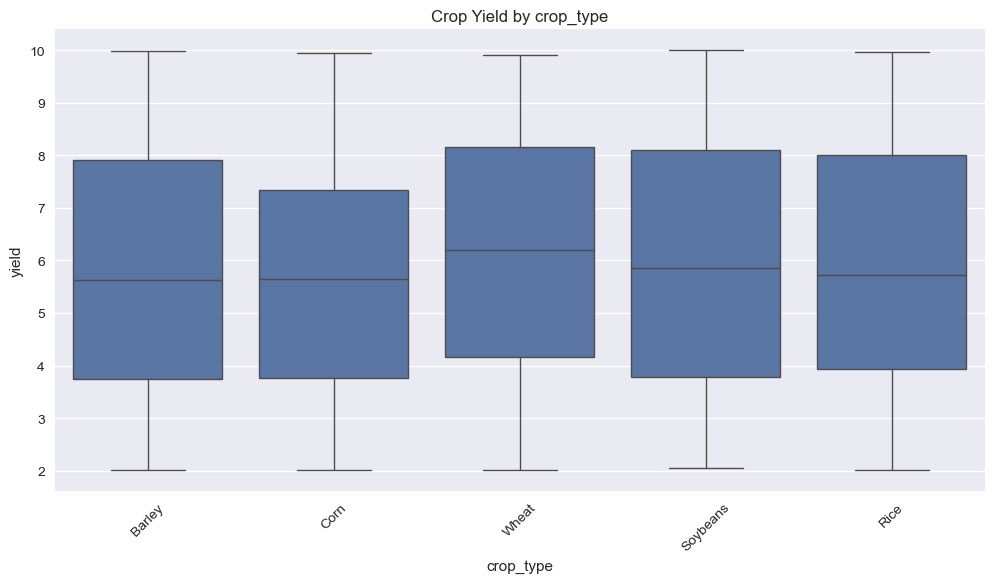

In [15]:
# Set up the plotting area for feature distributions
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3

plt.figure(figsize=(15, 5*n_rows))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, 3, i)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(12, 8))
numerical_corr = df[numerical_cols].corr()
sns.heatmap(numerical_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Box plots for categorical variables vs yield
categorical_cols = ['soil_type', 'weather_condition', 'crop_type']
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=col, y='yield')
    plt.title(f'Crop Yield by {col}')
    plt.xticks(rotation=45)
    plt.show()

## 3. Data Preprocessing and Feature Engineering

We'll create four different combinations of preprocessing:
1. One-Hot Encoding + MinMax Scaling
2. One-Hot Encoding + Standard Scaling
3. Leave-One-Out Encoding + MinMax Scaling
4. Leave-One-Out Encoding + Standard Scaling

In [16]:
# Separate features and target
X = df.drop('yield', axis=1)
y = df['yield']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Identify categorical and numerical columns
categorical_cols = ['soil_type', 'weather_condition', 'crop_type']
numerical_cols = ['temperature', 'rainfall', 'humidity']

# Function to create preprocessed datasets
def preprocess_data(X_train, X_test, categorical_cols, numerical_cols, encoding='ohe', scaling='minmax'):
    # Create copies
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()
    
    # Encoding
    if encoding == 'ohe':
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # Updated parameter name
        encoded_train = encoder.fit_transform(X_train_processed[categorical_cols])
        encoded_test = encoder.transform(X_test_processed[categorical_cols])
        feature_names = encoder.get_feature_names_out(categorical_cols)
    else:  # leave-one-out
        encoder = LeaveOneOutEncoder()
        encoded_train = encoder.fit_transform(X_train_processed[categorical_cols], y_train)
        encoded_test = encoder.transform(X_test_processed[categorical_cols])
        feature_names = categorical_cols
    
    # Convert encoded arrays to dataframes
    if encoding == 'ohe':
        encoded_train_df = pd.DataFrame(encoded_train, columns=feature_names, index=X_train_processed.index)
        encoded_test_df = pd.DataFrame(encoded_test, columns=feature_names, index=X_test_processed.index)
    else:
        encoded_train_df = pd.DataFrame(encoded_train, columns=feature_names, index=X_train_processed.index)
        encoded_test_df = pd.DataFrame(encoded_test, columns=feature_names, index=X_test_processed.index)
    
    # Scaling
    if scaling == 'minmax':
        scaler = MinMaxScaler()
    else:  # standard
        scaler = StandardScaler()
    
    scaled_train = scaler.fit_transform(X_train_processed[numerical_cols])
    scaled_test = scaler.transform(X_test_processed[numerical_cols])
    
    # Combine scaled numerical and encoded categorical features
    scaled_train_df = pd.DataFrame(scaled_train, columns=numerical_cols, index=X_train_processed.index)
    scaled_test_df = pd.DataFrame(scaled_test, columns=numerical_cols, index=X_test_processed.index)
    
    X_train_final = pd.concat([scaled_train_df, encoded_train_df], axis=1)
    X_test_final = pd.concat([scaled_test_df, encoded_test_df], axis=1)
    
    return X_train_final, X_test_final, encoder, scaler

# Create all combinations
combinations = [
    ('ohe', 'minmax'),
    ('ohe', 'standard'),
    ('loo', 'minmax'),
    ('loo', 'standard')
]

# Create a directory for saving files if it doesn't exist
import os
if not os.path.exists('datasets'):
    os.makedirs('datasets')

preprocessed_data = {}
for encoding, scaling in combinations:
    key = f'{encoding}_{scaling}'
    X_train_processed, X_test_processed, encoder, scaler = preprocess_data(
        X_train, X_test, categorical_cols, numerical_cols, encoding, scaling
    )
    preprocessed_data[key] = {
        'X_train': X_train_processed,
        'X_test': X_test_processed,
        'encoder': encoder,
        'scaler': scaler
    }
    
    # Save preprocessed datasets
    pd.concat([X_train_processed, pd.Series('train', index=X_train_processed.index, name='split')], axis=1).to_csv(f'datasets/{key}_train.csv', index=False)
    pd.concat([X_test_processed, pd.Series('test', index=X_test_processed.index, name='split')], axis=1).to_csv(f'datasets/{key}_test.csv', index=False)
    
    # Save encoders and scalers
    with open(f'{key}_encoder.pkl', 'wb') as f:
        pickle.dump(encoder, f)
    with open(f'{key}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

print("Preprocessing complete and files saved!")

Training set shape: (800, 6)
Testing set shape: (200, 6)
Preprocessing complete and files saved!
Preprocessing complete and files saved!


## 4. Model Development and Evaluation

Let's train and evaluate different regression models on all preprocessing combinations.


Training models on ohe_minmax preprocessed data:

Training Linear Regression...
Linear Regression Results:
MAE: 1.9686
MSE: 5.2129
RMSE: 2.2832
R2: -0.0306

Training Lasso...
Lasso Results:
MAE: 1.9564
MSE: 5.1411
RMSE: 2.2674
R2: -0.0164

Training Ridge...
Ridge Results:
MAE: 1.9686
MSE: 5.2129
RMSE: 2.2832
R2: -0.0306

Training Random Forest...
Random Forest Results:
MAE: 1.9295
MSE: 5.1973
RMSE: 2.2798
R2: -0.0275

Training models on ohe_standard preprocessed data:

Training Linear Regression...
Linear Regression Results:
MAE: 1.9686
MSE: 5.2129
RMSE: 2.2832
R2: -0.0306

Training Lasso...
Lasso Results:
MAE: 1.9561
MSE: 5.1468
RMSE: 2.2687
R2: -0.0176

Training Ridge...
Ridge Results:
MAE: 1.9686
MSE: 5.2129
RMSE: 2.2832
R2: -0.0306

Training Random Forest...
Random Forest Results:
MAE: 1.9295
MSE: 5.1973
RMSE: 2.2798
R2: -0.0275

Training models on ohe_standard preprocessed data:

Training Linear Regression...
Linear Regression Results:
MAE: 1.9686
MSE: 5.2129
RMSE: 2.2832
R2: -0.

,Preprocessing,Model,MAE,MSE,RMSE,R2
12,loo_standard,Linear Regression,1.910142,4.984550,2.232611,0.014526
8,loo_minmax,Linear Regression,1.910142,4.984550,2.232611,0.014526
10,loo_minmax,Ridge,1.910152,4.984592,2.232620,0.014518
14,loo_standard,Ridge,1.910152,4.984593,2.232620,0.014517
9,loo_minmax,Lasso,1.921978,5.014027,2.239202,0.008698
13,loo_standard,Lasso,1.921455,5.017361,2.239947,0.008039
1,ohe_minmax,Lasso,1.956360,5.141140,2.267408,-0.016433
5,ohe_standard,Lasso,1.956088,5.146820,2.268660,-0.017556
11,loo_minmax,Random Forest,1.951053,5.149926,2.269345,-0.018170
15,loo_standard,Random Forest,1.951053,5.149926,2.269345,-0.018170


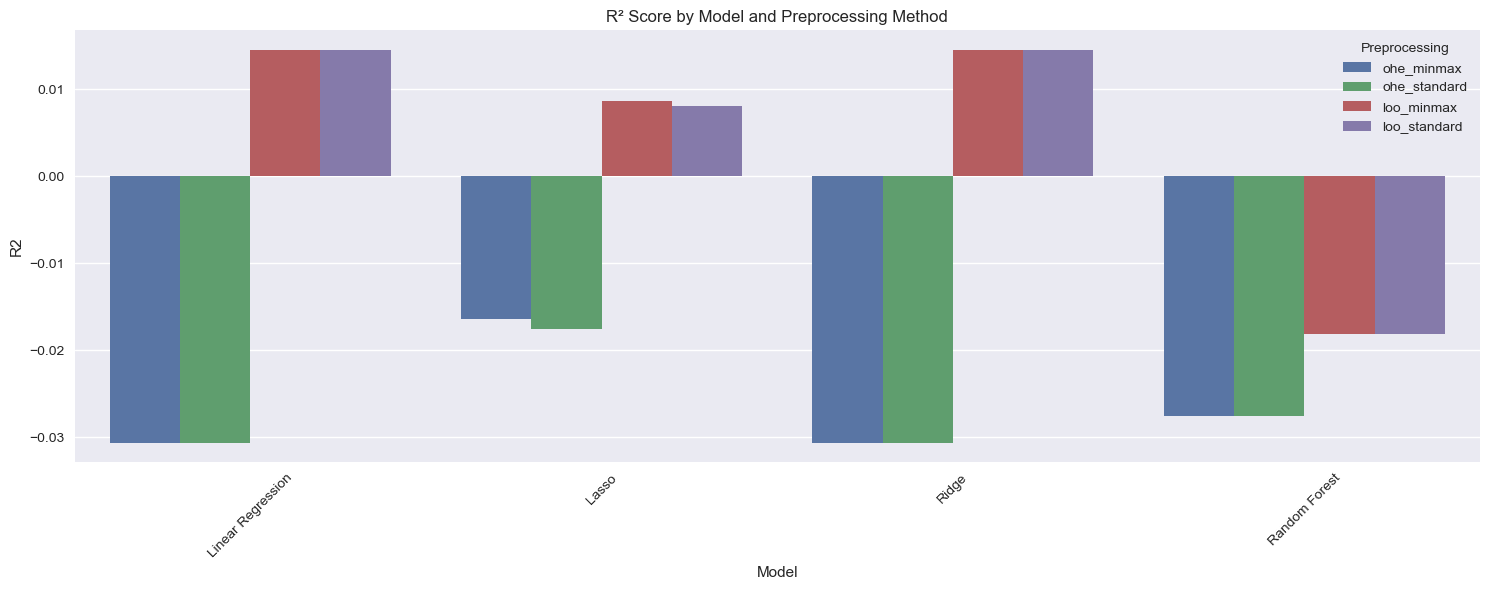

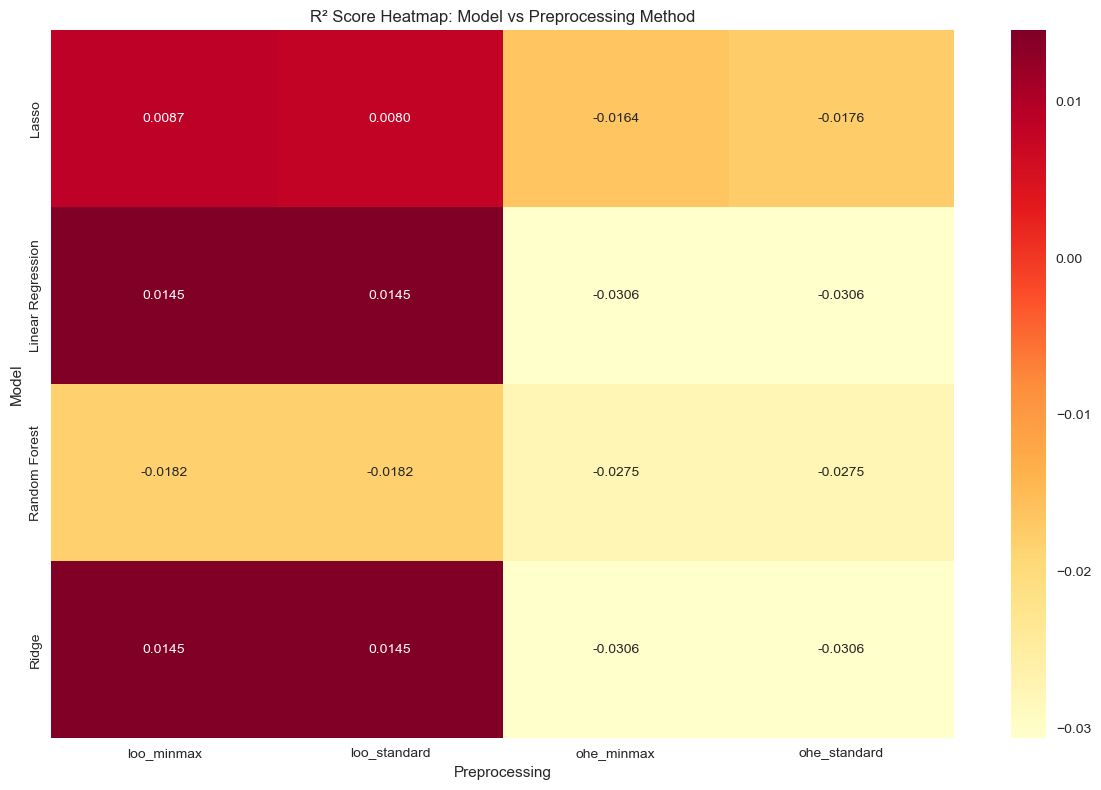

In [17]:
# Define models to test
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(alpha=0.01),
    'Ridge': Ridge(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Function to evaluate models
def evaluate_model(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

# Create results table
results = []

# Train and evaluate models
for prep_name, prep_data in preprocessed_data.items():
    print(f"\nTraining models on {prep_name} preprocessed data:")
    print("=" * 50)
    
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        
        # Train model
        model.fit(prep_data['X_train'], y_train)
        
        # Make predictions
        y_pred = model.predict(prep_data['X_test'])
        
        # Evaluate
        metrics = evaluate_model(y_test, y_pred)
        
        # Store results
        results.append({
            'Preprocessing': prep_name,
            'Model': model_name,
            **metrics
        })
        
        print(f"{model_name} Results:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")

# Convert results to DataFrame and sort by R2 score
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('R2', ascending=False)

# Display results
print("\nModel Evaluation Results (sorted by R2 score):")
print("=" * 100)
display(results_df_sorted)

# Save results
results_df_sorted.to_csv('model_evaluation_results.csv', index=False)

# Create visualizations of the results
plt.figure(figsize=(15, 6))
sns.barplot(data=results_df, x='Model', y='R2', hue='Preprocessing')
plt.title('R² Score by Model and Preprocessing Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create a heatmap of all metrics
plt.figure(figsize=(12, 8))
pivot_table = results_df.pivot_table(
    index='Model', 
    columns='Preprocessing', 
    values='R2'
)
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')
plt.title('R² Score Heatmap: Model vs Preprocessing Method')
plt.tight_layout()
plt.show()

## 5. Pipeline Creation and Model Deployment

Create and save a pipeline using the best performing model and preprocessing combination.

In [18]:
# Get the best model configuration
best_result = results_df_sorted.iloc[0]
best_preprocessing = best_result['Preprocessing']
best_model_name = best_result['Model']

print(f"Best Configuration:")
print(f"Preprocessing: {best_preprocessing}")
print(f"Model: {best_model_name}")
print(f"R2 Score: {best_result['R2']:.4f}")

# Get the best encoder and scaler
best_encoder = preprocessed_data[best_preprocessing]['encoder']
best_scaler = preprocessed_data[best_preprocessing]['scaler']
best_model = models[best_model_name]

# Create and save the final pipeline
final_pipeline = {
    'encoder': best_encoder,
    'scaler': best_scaler,
    'model': best_model,
    'categorical_cols': categorical_cols,
    'numerical_cols': numerical_cols
}

# Save the pipeline
with open('final_yield_pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

print("\nPipeline saved successfully!")

# Function to make predictions using the pipeline
def predict_yield(data, pipeline):
    # Prepare the data
    X = pd.DataFrame(data)
    
    # Apply encoding
    if isinstance(pipeline['encoder'], OneHotEncoder):
        encoded_data = pipeline['encoder'].transform(X[pipeline['categorical_cols']])
        encoded_df = pd.DataFrame(
            encoded_data,
            columns=pipeline['encoder'].get_feature_names_out(pipeline['categorical_cols']),
            index=X.index
        )
    else:
        encoded_data = pipeline['encoder'].transform(X[pipeline['categorical_cols']])
        encoded_df = pd.DataFrame(
            encoded_data,
            columns=pipeline['categorical_cols'],
            index=X.index
        )
    
    # Apply scaling
    scaled_data = pipeline['scaler'].transform(X[pipeline['numerical_cols']])
    scaled_df = pd.DataFrame(
        scaled_data,
        columns=pipeline['numerical_cols'],
        index=X.index
    )
    
    # Combine features
    X_processed = pd.concat([scaled_df, encoded_df], axis=1)
    
    # Make prediction
    return pipeline['model'].predict(X_processed)

# Example usage with a sample data point
print("\nTesting the pipeline with a sample data point:")
sample_data = X.iloc[[0]].copy()
print("\nInput Data:")
display(sample_data)

prediction = predict_yield(sample_data, final_pipeline)
print(f"\nPredicted Yield: {prediction[0]:.2f} tons/hectare")

# Save additional information about the best model
model_info = {
    'best_preprocessing': best_preprocessing,
    'best_model': best_model_name,
    'performance_metrics': {
        'R2': best_result['R2'],
        'MAE': best_result['MAE'],
        'MSE': best_result['MSE'],
        'RMSE': best_result['RMSE']
    }
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("\nModel information saved successfully!")

Best Configuration:
Preprocessing: loo_standard
Model: Linear Regression
R2 Score: 0.0145

Pipeline saved successfully!

Testing the pipeline with a sample data point:

Input Data:


,temperature,rainfall,humidity,soil_type,weather_condition,crop_type
0,22.490802,185.132929,53.085284,Sandy,Sunny,Barley



Predicted Yield: 5.82 tons/hectare

Model information saved successfully!


In [19]:
# Create a proper scikit-learn Pipeline with the best model and preprocessing steps
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Get the best model configuration
best_result = results_df_sorted.iloc[0]
best_preprocessing = best_result['Preprocessing']
best_model_name = best_result['Model']

print(f"Creating pipeline with:")
print(f"Preprocessing: {best_preprocessing}")
print(f"Model: {best_model_name}")

# Get the best components
encoding_type, scaling_type = best_preprocessing.split('_')
best_encoder = preprocessed_data[best_preprocessing]['encoder']
best_scaler = preprocessed_data[best_preprocessing]['scaler']
best_model = models[best_model_name]

# Create preprocessing steps
numeric_transformer = best_scaler
categorical_transformer = best_encoder

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create the pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', best_model)
])

# Fit the pipeline
X = df.drop('yield', axis=1)
y = df['yield']
final_pipeline.fit(X, y)

# Save the pipeline
import joblib
joblib.dump(final_pipeline, 'final_yield_pipeline.pkl')

print("\nPipeline saved successfully!")

# Test the pipeline
sample_data = X.iloc[[0]].copy()
print("\nTesting the pipeline with sample data:")
print("\nInput Data:")
display(sample_data)
prediction = final_pipeline.predict(sample_data)
print(f"\nPredicted Yield: {prediction[0]:.2f} tons/hectare")

Creating pipeline with:
Preprocessing: loo_standard
Model: Linear Regression

Pipeline saved successfully!

Testing the pipeline with sample data:

Input Data:


,temperature,rainfall,humidity,soil_type,weather_condition,crop_type
0,22.490802,185.132929,53.085284,Sandy,Sunny,Barley



Predicted Yield: 5.72 tons/hectare
